# Explore Data Before Downloading

OPS collections can be tens to hundreds of gigabytes. Before committing to a download, you usually want to take a look at subsets of the data and confirm it covers the perturbations you care about, the cells are healthy, the effect sizes look reasonable, and the feature set matches what your downstream analysis needs.

When you want to slice the data and/or explore it in more depth, e.g., count cells per perturbation, rank features by significance, plot a custom feature distribution, test a hypothesis, you can use the OPS analysis code.

> **Download and run the notebook locally:** [OPS Analysis](https://github.com/chanzuckerberg/ops-schema/blob/main/docs/analysis/inspect-data/ops_analysis.ipynb)

**What the notebook covers:**

- Load the collection's `collection_metadata.yaml`, `cell_data.parquet`, and `aggregated_data.h5ad`
- **Slice** cells by perturbation, by non-targeting control, by cell-cycle phase, by minimum cell count, etc.
- **Slice** perturbations by significance on a chosen feature, and features most affected by a chosen perturbation
- **Visualize:** feature distribution vs control, single-perturbation volcano, all-perturbation scatter for one feature, the perturbation embedding, top-perturbation × top-feature heatmap, cluster composition


### Run this notebook

This notebook streams an OPS collection directly from the public S3 bucket, which lets you explore a collection from a Jupyter environment without downloading entire collections locally.

If you decide a collection is worth downloading, the [**Downloading a local copy**](#downloading-a-local-copy) section at the end shows how to get the whole collection with the `biohub-data-cli` in a single command.

## Setup

In [1]:
%pip install -q s3fs anndata pyarrow pandas matplotlib seaborn pyyaml fsspec biohub-data-cli

In [22]:
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import fsspec
import s3fs
import pyarrow.parquet as pq

# Anonymous (unsigned) S3 access
S3_OPTS = {"anon": True}
fs = s3fs.S3FileSystem(anon=True)

## Resolve a collection ID to its storage locations

Using the Altair collection (https://biohub.ai/ops-explorer?collection=6a3f8b91-1c5e-4d3a-9b4c-f7e0a2d8b6f3) in this example

In [23]:
from biohub_data_cli.download import fetch_collection

COLLECTION_ID = "6a3f8b91-1c5e-4d3a-9b4c-f7e0a2d8b6f3"
collection = fetch_collection(COLLECTION_ID)

print(f"{collection.title}  (slug={collection.slug})")
for d in collection.datasets:
    size = f"{d.file_size_bytes / 1e6:.1f} MB" if d.file_size_bytes else "?"
    print(f"  - {d.slug:20s} {size:>10s}  ->  {d.urls[0]}")

Leonetti — OPS atlas  (slug=leonetti)
  - cropseq-pseudobulk     241.3 MB  ->  s3://cellxstate-data-dev/sources/CropSeq_June2025_perturbation_lvl_ops_2026_05_07.h5ad
  - ops-atlas               12.4 MB  ->  s3://ops-explorer-public/leonetti_ops/ops_data_portal_submission/v1.0.20260521/atlas_reformatted


In [24]:
# Verified-live public prefix for the Leonetti OPS atlas. Once the catalog
# `ops-atlas` URI resolves to a published path, replace this with:
#     ops_atlas = next(d for d in collection.datasets if d.slug == "ops-atlas")
#     BASE = ops_atlas.urls[0]
BASE = "s3://ops-explorer-public/leonetti_ops/ops_data_portal_submission/v1.0.20260521"
ATLAS = f"{BASE}/atlas"
print("Streaming from:", BASE)

Streaming from: s3://ops-explorer-public/leonetti_ops/ops_data_portal_submission/v1.0.20260521


## Inspect the prefix in S3

Listing the prefix shows which artifacts are present

In [25]:
for entry in fs.ls(ATLAS, detail=True):
    name = entry["name"].rsplit("/", 1)[-1]
    kind = entry["type"]
    size_mb = entry["size"] / 1e6
    print(f"{kind:9s}  {size_mb:>9.2f} MB  {name}")

file           11.70 MB  aggregated_data.h5ad
directory       0.00 MB  cell_features
directory       0.00 MB  examples.zarr
directory       0.00 MB  examples_subset.zarr
file            0.01 MB  examples_zarr_channel_map.yaml
file            0.00 MB  experimental_metadata.yaml
file            4.63 MB  feature_definitions.csv
file            0.33 MB  perturbation_library.csv
directory       0.00 MB  sample_cell_pngs


## Load the experiment metadata

`experimental_metadata.yaml` holds the experiment/library/microscope/pipeline
context shared across the collection.

In [26]:
with fsspec.open(f"{ATLAS}/experimental_metadata.yaml", "r", anon=True) as fh:
    experimental_metadata = yaml.safe_load(fh)

# Top-level sections; drill into any of them as needed.
for section, body in experimental_metadata.items():
    keys = list(body) if isinstance(body, dict) else body
    print(f"{section:12s}: {keys}")

experiment  : ['pseudobulk', 'organism_ontology_term_id', 'organism', 'tissue_ontology_term_id', 'tissue', 'tissue_type', 'disease_ontology_term_id', 'disease', 'development_stage_ontology_term_id', 'development_stage', 'assay_ontology_term_id', 'assay', 'title']
cellular    : ['cell_line', 'cell_line_atcc_id', 'cellosaurus_id', 'cell_type', 'cell_type_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity', 'donor_age_years', 'growth_conditions', 'plate_type', 'seeding', 'induction']
library     : ['vector', 'protocol_name', 'protocol_references', 'gene_selection', 'positive_controls', 'negative_controls']
iss         : ['cycles', 'objective', 'objective_numerical_aperture', 'objective_immersion', 'chemistry', 'fixation', 'fp_bleaching', 'rt_primer', 'rt_enzyme', 'rt_conditions', 'amplification', 'sequencing_primer', 'dna_stain', 'interim_storage', 'channels']
phenotype   : ['objective', 'objective_finder_url', 'objective_numerical_aperture', 'objective_immersion', 'expos

## Load the per-perturbation aggregated AnnData

`atlas/aggregated_data.h5ad` is the visualization-layer artifact: rows are
perturbations, columns are the standardized morphological feature set.
`.X` stores per-perturbation effect sizes; `.layers["neg_log10_fdr"]` stores
significance; `.obsm` stores 2D embeddings.

In [27]:
with fsspec.open(f"{ATLAS}/aggregated_data.h5ad", "rb", anon=True) as fh:
    agg = ad.read_h5ad(fh)
agg

AnnData object with n_obs × n_vars = 1052 × 875
    obs: 'aggregate_id', 'perturbation_id', 'gene_id', 'gene_symbol', 'n_cells', 'role', 'n_experiments', 'geneKO_name', 'guides', 'LongName', 'NCBI_ID', 'cluster_group_paper_low_res', 'cluster_group_paper_high_res', 'cluster_group_paper_low_res_label', 'cluster_group_paper_high_res_label'
    var: 'feature_name', 'feature_type', 'compartment'
    uns: 'cluster_display_names', 'default_embedding', 'observation_unit', 'schema_version', 'title'
    obsm: 'X_phate', 'X_umap'
    layers: 'neg_log10_fdr', 'p_values'

The standardized feature set is partitioned by type and compartment, and
perturbations are tagged as `targeting` vs `control` in `obs["role"]`.

In [28]:
print("perturbations    :", agg.n_obs, " (", agg.obs.role.value_counts().to_dict(), ")")
print("features         :", agg.n_vars)
print("feature types    :", agg.var.feature_type.value_counts().to_dict())
print("compartments     :", agg.var.compartment.value_counts().to_dict())
print("default embedding:", agg.uns["default_embedding"])
print("layers           :", list(agg.layers))

perturbations    : 1052  ( {'targeting': 1000, 'control': 52} )
features         : 875
feature types    : {'intensity': 698, 'correlation': 169, 'shape': 8}
compartments     : {'cell': 480, 'nucleus': 395}
default embedding: X_umap
layers           : ['neg_log10_fdr', 'p_values']


### A note on the FDR threshold

Unlike some collections, this atlas doesn't ship a recommended cutoff in
`uns`, so we derive the conventional one from the `neg_log10_fdr` layer:
−log10(0.05) ≈ 1.30. Check `agg.uns` on other collections before assuming.

In [29]:
FDR_THRESH = float(-np.log10(0.05))  # ~1.301
print(f"neg_log10_fdr cutoff: {FDR_THRESH:.3f}  (FDR < 0.05)")

neg_log10_fdr cutoff: 1.301  (FDR < 0.05)


## Read the per-cell parquet *without* downloading it

`cell_data.parquet` has one row per cell. We don't need the whole file to
explore it. Parquet's footer lets us read the schema and row counts with a
tiny ranged request, and column projection fetches only the columns we ask
for. Here we point at one screen (`Biohub_OPS0001`).

In [30]:
PARQUET = f"{BASE}/datasets/Biohub_OPS0001/cell_data.parquet"

# Reads only the parquet footer (~KB), not the 36 MB of data.
pf = pq.ParquetFile(fs.open(PARQUET, "rb"))
print(f"rows: {pf.metadata.num_rows:,}   columns: {pf.metadata.num_columns}   row_groups: {pf.num_row_groups}")
print("columns:", pf.schema_arrow.names)

rows: 831,587   columns: 10   row_groups: 1
columns: ['plate', 'well_row', 'well_col', 'tile', 'x', 'y', 'cell_uid', 'barcode', 'perturbation_id', 'bounding_box']


In [31]:
# Column projection: fetch only the identifier columns, skip the wide ones.
# On a file with many row groups, predicate pushdown would also skip rows;
# this screen is a single row group, so we project columns then filter in pandas.
id_cols = ["cell_uid", "well_row", "well_col", "tile", "perturbation_id"]
cells = pf.read(columns=id_cols).to_pandas()
print("shape:", cells.shape)
cells.head()

shape: (831587, 5)


,cell_uid,well_row,well_col,tile,perturbation_id
0,Biohub_OPS0001_A1_2027_19418950,A,1,2027,MBD5
1,Biohub_OPS0001_A1_2027_19418939,A,1,2027,MAD2L2
2,Biohub_OPS0001_A1_2026_17929977,A,1,2026,SPCS3
3,Biohub_OPS0001_A1_2026_17929976,A,1,2026,PARP1
4,Biohub_OPS0001_A1_2026_17929949,A,1,2026,PPP1CA


### Slice: all cells for one perturbation

In [32]:
# Pick a perturbation of interest e.g. given:
pert = 'STMN1'
gene_cells = cells[cells.perturbation_id == pert]
print(f"{len(gene_cells)} cells for perturbation {pert!r}")
gene_cells.head()

891 cells for perturbation 'STMN1'


,cell_uid,well_row,well_col,tile,perturbation_id
257,Biohub_OPS0001_A1_5017_10570766,A,1,5017,STMN1
1747,Biohub_OPS0001_A1_3024_16439019,A,1,3024,STMN1
1777,Biohub_OPS0001_A1_3024_16439007,A,1,3024,STMN1
1790,Biohub_OPS0001_A1_3024_16439002,A,1,3024,STMN1
1821,Biohub_OPS0001_A1_3024_16438980,A,1,3024,STMN1


### Slice: perturbations with enough cells for robust per-cell statistics

Drop perturbations with too few cells before running tests on the
cell-level distribution.

In [33]:
min_cells = 50
counts = cells.perturbation_id.value_counts()
robust = counts[counts >= min_cells]
print(f"{len(robust)} perturbations with >= {min_cells} cells "
      f"(out of {cells.perturbation_id.nunique()})")
robust.head()

1001 perturbations with >= 50 cells (out of 1001)


perturbation_id
NTC        57868
AMMECR1     1508
SLC2A8      1391
ZNF219      1383
UHRF1       1326
Name: count, dtype: int64

## Slice: perturbations that significantly change a feature

The `neg_log10_fdr` layer gives −log10(FDR) for every (perturbation, feature)
pair. Fix a feature, rank perturbations, keep those past the cutoff.

In [34]:
# Pick the single most-significant (perturbation, feature) pair to drive the demo.
nlf = agg.layers["neg_log10_fdr"]
i_max, j_max = np.unravel_index(np.asarray(nlf).argmax(), nlf.shape)
feature = agg.var_names[j_max]

fdr_col = np.asarray(nlf[:, j_max]).ravel()
sig = pd.Series(fdr_col, index=agg.obs_names).sort_values(ascending=False)
sig = sig[sig >= FDR_THRESH]
print(f"{len(sig)} perturbations significantly affect {feature!r}")
sig.head(10)

971 perturbations significantly affect 'cell_correlation_Rb_pRb'


aggregate_id
ABCE1     37.929783
AATF      37.929783
AARS1     37.929783
WDR12     37.929783
ZNF574    37.929783
WDR36     37.929783
XAB2      37.929783
HAUS5     37.929783
XPO1      37.929783
HAUS4     37.929783
dtype: float32

## Slice: features most affected by one perturbation

Pick a perturbation and rank every feature by significance.

In [35]:
pert = 'STMN1'
i = agg.obs_names.get_loc(pert)

ranked = pd.DataFrame({
    "feature": agg.var_names,
    "effect_size": np.asarray(agg.X[i]).ravel(),
    "neg_log10_fdr": np.asarray(agg.layers["neg_log10_fdr"][i]).ravel(),
})
print(f"top features for {pert!r}")
ranked.sort_values("neg_log10_fdr", ascending=False).head(10)

top features for 'STMN1'


,feature,effect_size,neg_log10_fdr
320,cell_area,0.148976,37.929779
147,cell_MAP1LC3B_integrated,0.242330,31.518782
91,cell_FastAct_SPY555_Live_Cell_Dye_integrated,0.190579,30.695480
299,cell_VAPA_integrated,0.283468,28.892208
28,cell_CLTA_integrated,0.288283,21.581137
220,cell_Phalloidin_mean_edge,-0.310142,20.678343
243,cell_SEC61B_integrated,0.172197,20.319662
142,cell_LysoTracker_live-cell_dye_mean,0.207815,19.944332
222,cell_Phalloidin_mean_frac_3,-0.303293,19.435497
227,cell_Phase_mean_edge,0.101506,18.657616


## Visualize: volcano plot for one perturbation

Each dot is one feature. The x-axis is the perturbation's effect size; the
y-axis is −log10(FDR). The dashed line is the FDR < 0.05 cutoff.

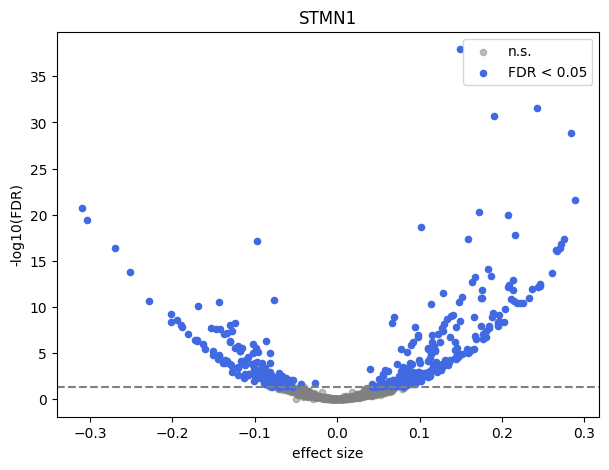

In [36]:
effect = np.asarray(agg.X[i]).ravel()
nlf_pert = np.asarray(agg.layers["neg_log10_fdr"][i]).ravel()
sig_mask = nlf_pert >= FDR_THRESH

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(effect[~sig_mask], nlf_pert[~sig_mask], s=20, color="grey", alpha=0.5, label="n.s.")
ax.scatter(effect[sig_mask], nlf_pert[sig_mask], s=20, color="royalblue", label="FDR < 0.05")
ax.axhline(FDR_THRESH, color="grey", linestyle="--")
ax.set_xlabel("effect size")
ax.set_ylabel("-log10(FDR)")
ax.set_title(pert)
ax.legend()
plt.show()

## Visualize: every perturbation for one feature

Flip the volcano around. Fix the feature, scatter all perturbations.
Annotate the strongest hits.

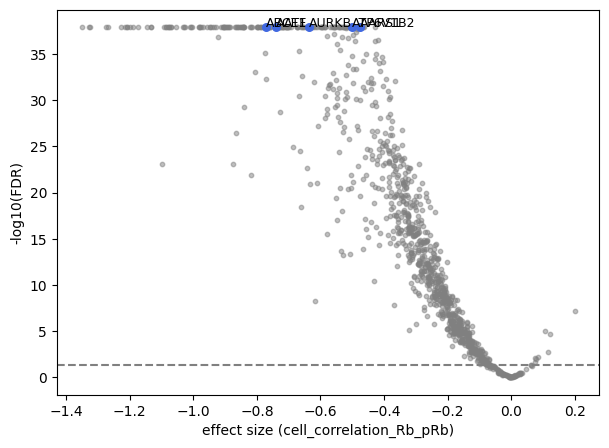

In [37]:
df = pd.DataFrame({
    "perturbation": agg.obs_names,
    "effect_size": np.asarray(agg.X[:, j_max]).ravel(),
    "neg_log10_fdr": np.asarray(agg.layers["neg_log10_fdr"][:, j_max]).ravel(),
})

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df.effect_size, df.neg_log10_fdr, s=10, alpha=0.5, color="grey")
ax.axhline(FDR_THRESH, color="grey", linestyle="--")
top = df.nlargest(5, "neg_log10_fdr")
ax.scatter(top.effect_size, top.neg_log10_fdr, s=30, color="royalblue")
for _, r in top.iterrows():
    ax.annotate(r.perturbation, (r.effect_size, r["neg_log10_fdr"]), fontsize=9)
ax.set_xlabel(f"effect size ({feature})")
ax.set_ylabel("-log10(FDR)")
plt.show()

## Visualize: perturbation embedding

`obsm` carries 2D embeddings for the visualization layer. Color by the
paper's low-resolution cluster assignment from `obs`.

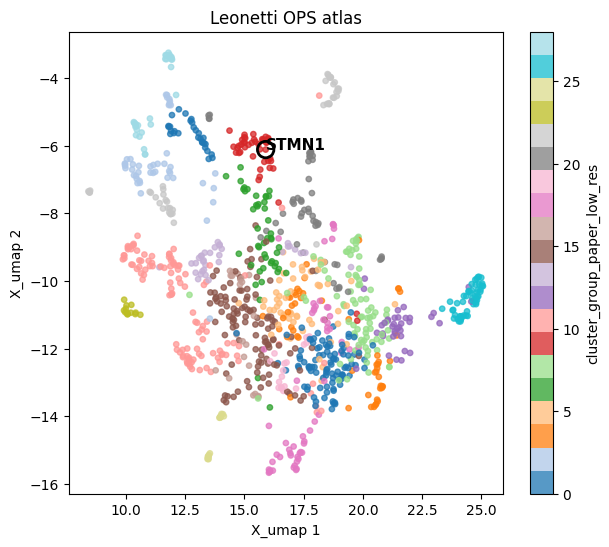

In [38]:
emb_key = agg.uns["default_embedding"]
coords = agg.obsm[emb_key]
clusters = agg.obs["cluster_group_paper_low_res"].astype(int)

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(coords[:, 0], coords[:, 1], c=clusters, cmap="tab20", s=15, alpha=0.75)
plt.colorbar(sc, label="cluster_group_paper_low_res", ax=ax)

p = agg.obsm[emb_key][i]
ax.scatter(p[0], p[1], s=140, edgecolor="black", facecolor="none", linewidth=2)
ax.annotate(pert, (p[0], p[1]), fontsize=11, fontweight="bold")

ax.set_xlabel(f"{emb_key} 1")
ax.set_ylabel(f"{emb_key} 2")
ax.set_title(agg.uns["title"])
plt.show()

## Visualize: heatmap of top perturbations × top features

Rank perturbations by total significance, pick the top features the same way,
and plot the effect-size submatrix.

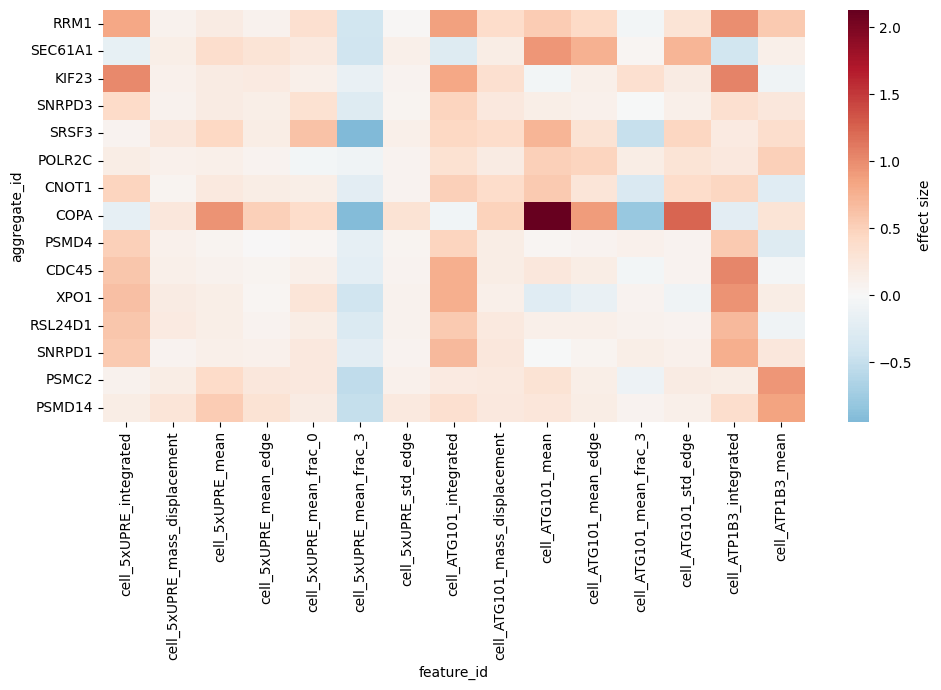

In [39]:
nlf_arr = np.asarray(agg.layers["neg_log10_fdr"])
per_pert_score = nlf_arr.sum(axis=1)
top_perts = pd.Series(per_pert_score, index=agg.obs_names).nlargest(15).index

per_feat_max = nlf_arr.max(axis=0)
top_feats = pd.Series(per_feat_max, index=agg.var_names).nlargest(15).index

mat = pd.DataFrame(
    np.asarray(agg[top_perts, top_feats].X),
    index=top_perts,
    columns=top_feats,
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(mat, cmap="RdBu_r", center=0, cbar_kws={"label": "effect size"}, ax=ax)
plt.tight_layout()
plt.show()

## Visualize: cluster composition

How many perturbations fall in each morphology cluster (using the paper's
low-res labels where available).

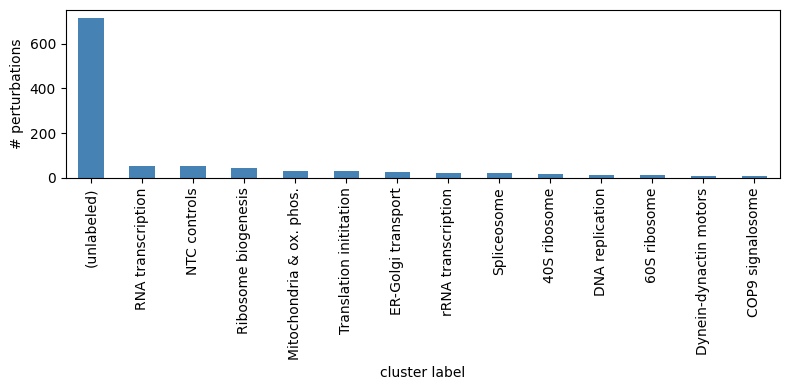

In [40]:
comp = agg.obs["cluster_group_paper_low_res_label"].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
comp.head(15).plot.bar(ax=ax, color="steelblue")
ax.set_xlabel("cluster label")
ax.set_ylabel("# perturbations")
plt.tight_layout()
plt.show()

## Downloading a local copy

When you do want a full local copy of a collection **after** exploring it, use the CLI.

```bash
# Preview the size budget — no bytes transferred
ops-data download collection 6a3f8b91-1c5e-4d3a-9b4c-f7e0a2d8b6f3 --dry-run

# Download the collection to ./data
ops-data download collection 6a3f8b91-1c5e-4d3a-9b4c-f7e0a2d8b6f3 -o ./data -y
```

Full reference: <https://chanzuckerberg.github.io/ops-schema/cli/>